<a href="https://colab.research.google.com/github/joao-victor-g-dev/analise-ids-cicids2017/blob/main/DataSet_CIC_IDS_2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO

In [ ]:
# ==========================================
# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO
# ==========================================
from google.colab import drive
import os
import zipfile

# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. Caminhos do diretório
zip_path = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/CSV/MachineLearningCSV.zip'
extract_path = '/content/dataset_csv'

print("🔍 Verificando integridade dos dados locais...")

# 3. Verificação Inteligente: Checa se a pasta tem arquivos CSV dentro
precisa_extrair = True
if os.path.exists(extract_path):
    # Conta quantos arquivos .csv existem em toda a árvore da pasta
    csv_encontrados = sum(1 for _, _, files in os.walk(extract_path) for f in files if f.endswith('.csv'))
    if csv_encontrados > 0:
        precisa_extrair = False
        print(f"✅ Diretório íntegro! Foram encontrados {csv_encontrados} arquivos CSV. Extração pulada.")
    else:
        print("⚠️ A pasta existe, mas está VAZIA. Forçando nova extração...")

# 4. Extração (se necessária)
if precisa_extrair:
    os.makedirs(extract_path, exist_ok=True)
    print("⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Dataset extraído com sucesso para o armazenamento local!")
    except Exception as e:
        print(f"❌ Erro ao tentar extrair o arquivo: {e}")
        print("Verifique se o caminho do arquivo .zip está 100% correto.")

Mounted at /content/drive
🔍 Verificando integridade dos dados locais...
⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...
✅ Dataset extraído com sucesso para o armazenamento local!


# MÓDULO 02: SELEÇÃO E EXPLORAÇÃO DO DIA (Busca Recursiva Avançada)

In [ ]:
# ==========================================
# MÓDULO 02: SELEÇÃO E EXPLORAÇÃO DO DIA (Busca Recursiva Avançada)
# ==========================================
import pandas as pd
import os
import shutil

# 1. Configuração de caminhos base
extract_path = '/content/dataset_csv'
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
os.makedirs(DIRETORIO_DATA, exist_ok=True)

print("🔍 Inspecionando diretórios em busca de arquivos CSV...")

# 2. Busca Recursiva (Encontra os CSVs não importa o quão fundo estejam na pasta)
caminhos_csv = {}
indice = 0

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.csv'):
            caminhos_csv[indice] = {
                'nome': file,
                'caminho_completo': os.path.join(root, file)
            }
            indice += 1

# 3. Validação de segurança
if not caminhos_csv:
    raise FileNotFoundError("🚨 Erro Crítico: Nenhum arquivo CSV encontrado em toda a pasta extraída. Por favor, execute o Módulo 01 novamente nesta sessão.")

print("\n📊 Arquivos CSV localizados com sucesso:")
for i, dados in caminhos_csv.items():
    print(f" [{i}] {dados['nome']}")

# 4. Seleção do arquivo (Ajuste o índice_escolhido para o número correspondente à Terça-feira)
# Olhe a lista impressa acima e mude este número se necessário:
indice_escolhido = 1

arquivo_selecionado = caminhos_csv[indice_escolhido]['nome']
caminho_origem = caminhos_csv[indice_escolhido]['caminho_completo']

print(f"\nCarregando os dados de: {arquivo_selecionado}...")
df = pd.read_csv(caminho_origem)

# 5. Limpeza inicial para a exploração
df.columns = df.columns.str.strip()

print("\nDistribuição das classes neste arquivo:")
print(df['Label'].value_counts())

# 6. Salvar uma cópia estática para os módulos de Pré-processamento
caminho_destino = os.path.join(DIRETORIO_DATA, 'dia_selecionado.csv')
print("\nExportando arquivo para o Drive como ponto de partida unificado...")
shutil.copy(caminho_origem, caminho_destino)
print(f"✅ Concluído! Arquivo base fixado em: {caminho_destino}")

🔍 Inspecionando diretórios em busca de arquivos CSV...

📊 Arquivos CSV localizados com sucesso:
 [0] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 [1] Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 [2] Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 [3] Tuesday-WorkingHours.pcap_ISCX.csv
 [4] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 [5] Monday-WorkingHours.pcap_ISCX.csv
 [6] Friday-WorkingHours-Morning.pcap_ISCX.csv
 [7] Wednesday-workingHours.pcap_ISCX.csv

Carregando os dados de: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...

Distribuição das classes neste arquivo:
Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

Exportando arquivo para o Drive como ponto de partida unificado...
✅ Concluído! Arquivo base fixado em: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data/dia_selecionado.csv


# MÓDULO 03: PRÉ-PROCESSAMENTO E DIVISÃO (SPLIT)


In [ ]:
# ==========================================
# MÓDULO 03: PRÉ-PROCESSAMENTO E DIVISÃO (SPLIT)
# ==========================================
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Configuração de caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
CAMINHO_DIA_SELECIONADO = os.path.join(DIRETORIO_DATA, 'dia_selecionado.csv')
DIRETORIO_PROCESSADO = os.path.join(DIRETORIO_DATA, 'processed')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

# Criar pastas caso não existam
os.makedirs(DIRETORIO_PROCESSADO, exist_ok=True)
os.makedirs(DIRETORIO_ARTEFATOS, exist_ok=True)

print("1. Carregando os dados do dia selecionado...")
df = pd.read_csv(CAMINHO_DIA_SELECIONADO)

print("2. Executando limpeza estrutural...")
df.columns = df.columns.str.strip() # Remove espaços extras
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Separa Features e Target
X = df.drop(columns=['Label'])
y = df['Label']

print("3. Codificando as classes (Strings para Números)...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Salva o dicionário de classes (Artefato)
joblib.dump(label_encoder, os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))
print(f"   -> Classes encontradas: {list(label_encoder.classes_)}")

print("4. Dividindo em Treino (70%) e Teste (30%)...")
# Stratify garante que a proporção de ataques seja a mesma em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print("5. Exportando matrizes CRUAS (sem normalização)...")
# Usando formato Parquet por ser mais leve e rápido que CSV
X_train.to_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_train_raw.parquet'))
X_test.to_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_test_raw.parquet'))
np.save(os.path.join(DIRETORIO_PROCESSADO, 'y_train.npy'), y_train)
np.save(os.path.join(DIRETORIO_PROCESSADO, 'y_test.npy'), y_test)

print("✅ Módulo 03 concluído! Dados brutos divididos com sucesso.")

1. Carregando os dados do dia selecionado...
2. Executando limpeza estrutural...
3. Codificando as classes (Strings para Números)...
   -> Classes encontradas: ['BENIGN', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'Heartbleed']
4. Dividindo em Treino (70%) e Teste (30%)...
5. Exportando matrizes CRUAS (sem normalização)...
✅ Módulo 03 concluído! Dados brutos divididos com sucesso.


# 03.1: Normalização (Standart Scaler)


In [ ]:
# ==========================================
# MÓDULO 03.1: NORMALIZAÇÃO (STANDARD SCALER)
# ==========================================
import pandas as pd
import os
import joblib
from sklearn.preprocessing import StandardScaler

# 1. Configuração de caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
DIRETORIO_PROCESSADO = os.path.join(DIRETORIO_DATA, 'processed')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando as matrizes CRUAS do Módulo 03...")
X_train_raw = pd.read_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_train_raw.parquet'))
X_test_raw = pd.read_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_test_raw.parquet'))

print("2. Aplicando Normalização (StandardScaler)...")
scaler = StandardScaler()
# Aprende a distribuição SÓ do treino (evita data leakage)
X_train_scaled_array = scaler.fit_transform(X_train_raw)
X_test_scaled_array = scaler.transform(X_test_raw)

# Salva a regra de normalização (Artefato)
joblib.dump(scaler, os.path.join(DIRETORIO_ARTEFATOS, 'scaler_standard.joblib'))

print("3. Exportando matrizes NORMALIZADAS...")
# Retorna para DataFrame para manter o nome das colunas intacto
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train_raw.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test_raw.columns)

# Salva a versão final que o modelo vai ler
X_train_scaled.to_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_train.parquet'))
X_test_scaled.to_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_test.parquet'))

print("✅ Módulo 03.1 concluído! Dados normalizados e prontos para a IA.")

1. Carregando as matrizes CRUAS do Módulo 03...
2. Aplicando Normalização (StandardScaler)...
3. Exportando matrizes NORMALIZADAS...
✅ Módulo 03.1 concluído! Dados normalizados e prontos para a IA.


# MÓDULO 04: TREINAMENTO E AVALIAÇÃO (BASELINE)


1. Carregando dados normalizados e artefatos do Módulo 03...
2. Treinando o modelo (Random Forest Baseline)...
   ⏳ Isso pode levar alguns minutos dependendo do volume de dados...
3. Validando o modelo com os dados de Teste invisíveis...

📊 RELATÓRIO DE CLASSIFICAÇÃO (MÉTRICAS PARA O ARTIGO):
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    131905
   DoS GoldenEye       1.00      0.99      1.00      3088
        DoS Hulk       1.00      1.00      1.00     69037
DoS Slowhttptest       1.00      0.99      0.99      1650
   DoS slowloris       0.99      0.99      0.99      1739
      Heartbleed       1.00      1.00      1.00         3

        accuracy                           1.00    207422
       macro avg       1.00      1.00      1.00    207422
    weighted avg       1.00      1.00      1.00    207422

4. Exportando o modelo treinado para uso futuro...


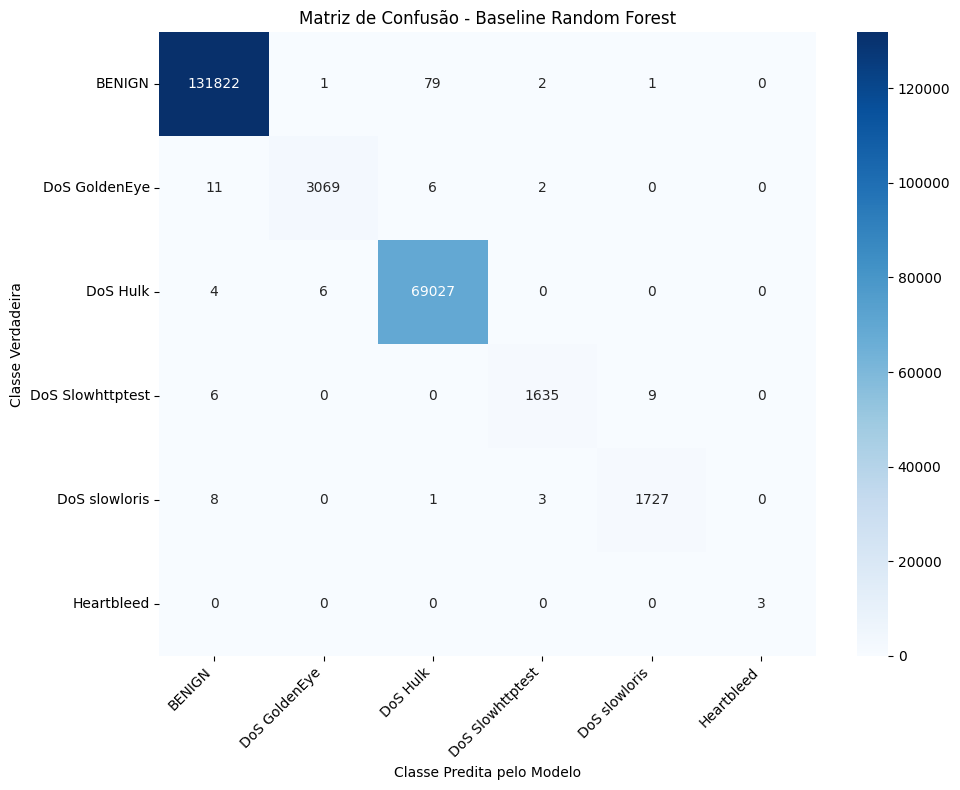

✅ Experimento de Baseline concluído com sucesso!


In [ ]:
# ==========================================
# MÓDULO 04: TREINAMENTO E AVALIAÇÃO (BASELINE)
# ==========================================
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
DIRETORIO_PROCESSADO = os.path.join(DIRETORIO_DATA, 'processed')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando dados normalizados e artefatos do Módulo 03...")
X_train = pd.read_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_train.parquet'))
X_test = pd.read_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_test.parquet'))
y_train = np.load(os.path.join(DIRETORIO_PROCESSADO, 'y_train.npy'))
y_test = np.load(os.path.join(DIRETORIO_PROCESSADO, 'y_test.npy'))

label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))
nomes_classes = label_encoder.classes_

print("2. Treinando o modelo (Random Forest Baseline)...")
print("   ⏳ Isso pode levar alguns minutos dependendo do volume de dados...")
# n_estimators=50 e max_depth=15 evitam que o modelo decore os dados (overfitting) e rodam rápido
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

print("3. Validando o modelo com os dados de Teste invisíveis...")
y_pred = modelo_rf.predict(X_test)

print("\n" + "="*60)
print("📊 RELATÓRIO DE CLASSIFICAÇÃO (MÉTRICAS PARA O ARTIGO):")
print("="*60)
relatorio = classification_report(y_test, y_pred, target_names=nomes_classes)
print(relatorio)

print("4. Exportando o modelo treinado para uso futuro...")
joblib.dump(modelo_rf, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_rf_baseline.joblib'))

# 5. Bônus para o Artigo: Gerando a Matriz de Confusão visual
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - Baseline Random Forest')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita pelo Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("✅ Experimento de Baseline concluído com sucesso!")

# MÓDULO 05: INTERPRETABILIDADE (FEATURE IMPORTANCE)

1. Carregando dados de treino e o modelo treinado...
2. Calculando o peso de decisão de cada atributo...

TOP 10 VARIÁVEIS MAIS IMPORTANTES:
                    Feature  Importancia
          Max Packet Length     0.103425
      Bwd Packet Length Max     0.082781
     Packet Length Variance     0.067492
       Avg Bwd Segment Size     0.065123
        Average Packet Size     0.048726
              Bwd Packets/s     0.045496
          Packet Length Std     0.045407
           Destination Port     0.042711
         Packet Length Mean     0.037490
Total Length of Bwd Packets     0.035755

3. Gerando visualização para exportação acadêmica...


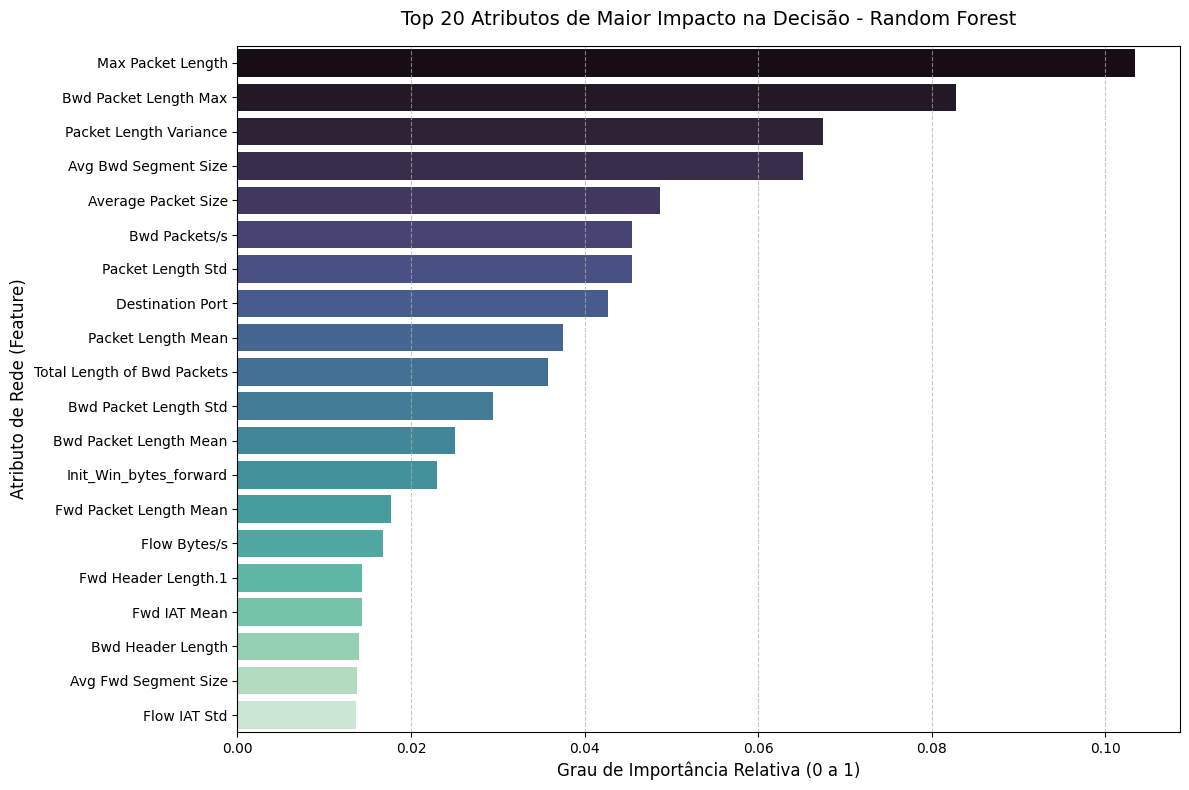

In [ ]:
# ==========================================
# MÓDULO 05: INTERPRETABILIDADE (FEATURE IMPORTANCE)
# ==========================================
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
DIRETORIO_PROCESSADO = os.path.join(DIRETORIO_DATA, 'processed')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando dados de treino e o modelo treinado...")
# Precisamos do X_train apenas para capturar o nome exato das colunas
X_train = pd.read_parquet(os.path.join(DIRETORIO_PROCESSADO, 'X_train.parquet'))
modelo_rf = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'modelo_rf_baseline.joblib'))

print("2. Calculando o peso de decisão de cada atributo...")
importancias = modelo_rf.feature_importances_
nomes_features = X_train.columns

# Criando um DataFrame organizado do maior para o menor peso
df_importancias = pd.DataFrame({
    'Feature': nomes_features,
    'Importancia': importancias
})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

print("\n" + "="*50)
print("TOP 10 VARIÁVEIS MAIS IMPORTANTES:")
print("="*50)
print(df_importancias.head(10).to_string(index=False))

print("\n3. Gerando visualização para exportação acadêmica...")
plt.figure(figsize=(12, 8))
# Plotando apenas as 20 principais para o gráfico ficar legível
sns.barplot(x='Importancia', y='Feature', data=df_importancias.head(20), hue='Feature', palette='mako', legend=False)
plt.title('Top 20 Atributos de Maior Impacto na Decisão - Random Forest', fontsize=14, pad=15)
plt.xlabel('Grau de Importância Relativa (0 a 1)', fontsize=12)
plt.ylabel('Atributo de Rede (Feature)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# MÓDULO 06: TESTE DE GENERALIZAÇÃO (OUT-OF-DISTRIBUTION)

1. Carregando a 'Mente' do Modelo de Quarta-feira...
2. Carregando dados inéditos de Segunda-feira (100% Benigno)...
3. Limpando os dados novos...
4. Aplicando a Normalização e Reconstruindo o DataFrame...
5. Realizando Predições no Novo Ambiente...

📊 TAXA DE FALSOS POSITIVOS (TESTE DE ESTRESSE):
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    529481
   DoS GoldenEye       0.00      0.00      0.00         0
        DoS Hulk       0.00      0.00      0.00         0
DoS Slowhttptest       0.00      0.00      0.00         0
   DoS slowloris       0.00      0.00      0.00         0
      Heartbleed       0.00      0.00      0.00         0

        accuracy                           1.00    529481
       macro avg       0.17      0.17      0.17    529481
    weighted avg       1.00      1.00      1.00    529481


6. Gerando Matriz de Confusão do Teste Cego...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

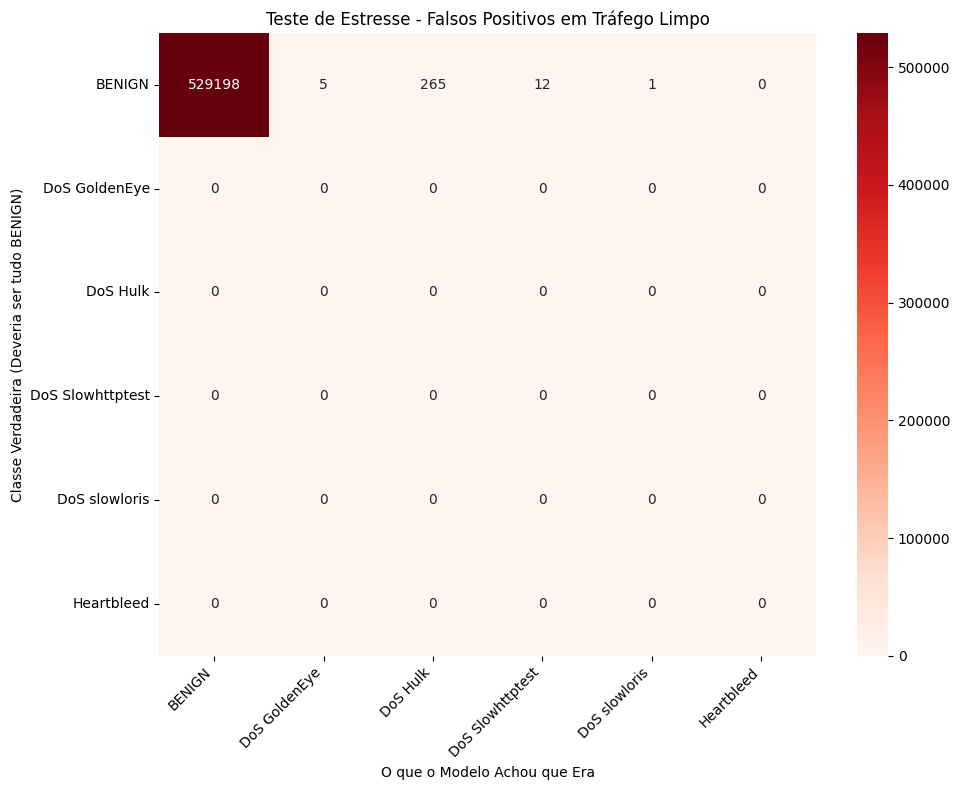

In [ ]:
# ==========================================
# MÓDULO 06: TESTE DE GENERALIZAÇÃO (Correção Scikit-Learn)
# ==========================================
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de caminhos
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'
CAMINHO_SEGUNDA = '/content/dataset_csv/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv'

print("1. Carregando a 'Mente' do Modelo de Quarta-feira...")
scaler = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'scaler_standard.joblib'))
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))
modelo_rf = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'modelo_rf_baseline.joblib'))

print("2. Carregando dados inéditos de Segunda-feira (100% Benigno)...")
df_monday = pd.read_csv(CAMINHO_SEGUNDA)

print("3. Limpando os dados novos...")
df_monday.columns = df_monday.columns.str.strip()
df_monday.replace([np.inf, -np.inf], np.nan, inplace=True)
df_monday.dropna(inplace=True)

X_novo = df_monday.drop(columns=['Label'])
y_novo = df_monday['Label']

# Codificando o y novo
y_novo_encoded = label_encoder.transform(y_novo)

print("4. Aplicando a Normalização e Reconstruindo o DataFrame...")
X_novo_scaled_array = scaler.transform(X_novo)
# CORREÇÃO 1: Devolver os nomes das colunas para evitar o Warning do Random Forest
X_novo_scaled = pd.DataFrame(X_novo_scaled_array, columns=X_novo.columns)

print("5. Realizando Predições no Novo Ambiente...")
y_pred_novo = modelo_rf.predict(X_novo_scaled)

print("\n" + "="*60)
print("📊 TAXA DE FALSOS POSITIVOS (TESTE DE ESTRESSE):")
print("="*60)
nomes_classes = label_encoder.classes_
# CORREÇÃO 2: Cria um índice numérico [0, 1, 2, 3, 4, 5] para forçar o mapeamento exato
indices_labels = list(range(len(nomes_classes)))

# Adicionamos o parâmetro 'labels=indices_labels'
print(classification_report(y_novo_encoded, y_pred_novo, labels=indices_labels, target_names=nomes_classes))

print("\n6. Gerando Matriz de Confusão do Teste Cego...")
plt.figure(figsize=(10, 8))
# Adicionamos o parâmetro 'labels' aqui também para a matriz ficar no formato 6x6
cm = confusion_matrix(y_novo_encoded, y_pred_novo, labels=indices_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Teste de Estresse - Falsos Positivos em Tráfego Limpo')
plt.ylabel('Classe Verdadeira (Deveria ser tudo BENIGN)')
plt.xlabel('O que o Modelo Achou que Era')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.show()

# MÓDULO 07: UNIFICAÇÃO DA SEMANA (BINARIZAÇÃO)

In [ ]:
# ==========================================
# MÓDULO 07: UNIFICAÇÃO DA SEMANA (BINARIZAÇÃO)
# ==========================================
import pandas as pd
import numpy as np
import os
import gc # Garbage Collector para salvar a memória RAM

# 1. Configuração de Caminhos
extract_path = '/content/dataset_csv'
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
os.makedirs(DIRETORIO_DATA, exist_ok=True)

print("🔍 Buscando todos os arquivos CSV extraídos da semana...")
arquivos_csv = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.csv'):
            arquivos_csv.append(os.path.join(root, file))

if not arquivos_csv:
    raise FileNotFoundError("Nenhum CSV encontrado. Execute o Módulo 01 para extrair os dados.")

print(f"✅ Foram encontrados {len(arquivos_csv)} arquivos para unificação.\n")

# 2. Processamento em Lote (Evita estourar a RAM)
lista_dataframes = []
total_linhas = 0

for i, arquivo in enumerate(arquivos_csv):
    nome_arquivo = os.path.basename(arquivo)
    print(f"[{i+1}/{len(arquivos_csv)}] Processando: {nome_arquivo}...")

    # Carrega o CSV
    df_temp = pd.read_csv(arquivo)

    # Limpeza Estrutural
    df_temp.columns = df_temp.columns.str.strip()
    df_temp.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_temp.dropna(inplace=True)

    # ==========================================
    # O PULO DO GATO: BINARIZAÇÃO DAS CLASSES
    # Se for BENIGN, continua BENIGN. Qualquer outra coisa vira ATTACK
    # ==========================================
    df_temp['Label'] = np.where(df_temp['Label'] == 'BENIGN', 'BENIGN', 'ATTACK')

    # Otimização de Memória (Reduz o tamanho dos dados numéricos pela metade)
    colunas_float = df_temp.select_dtypes(include=['float64']).columns
    df_temp[colunas_float] = df_temp[colunas_float].astype('float32')

    colunas_int = df_temp.select_dtypes(include=['int64']).columns
    df_temp[colunas_int] = df_temp[colunas_int].astype('int32')

    total_linhas += len(df_temp)
    lista_dataframes.append(df_temp)

    # Força a limpeza da RAM
    del df_temp
    gc.collect()

print("\n⚙️ Concatenando toda a semana em um único Super Dataset...")
df_unificado = pd.concat(lista_dataframes, ignore_index=True)

# Limpa a lista temporária da RAM
del lista_dataframes
gc.collect()

print("\n" + "="*50)
print("📊 RESUMO DO DATASET UNIFICADO (BINÁRIO):")
print("="*50)
print(f"Total de Registros: {len(df_unificado)}")
print("\nDistribuição das Classes:")
print(df_unificado['Label'].value_counts())

# 3. Exportando o arquivo final para o Drive
caminho_final = os.path.join(DIRETORIO_DATA, 'dataset_semana_unificada.parquet')
print("\n💾 Salvando o Super Dataset no Drive (formato Parquet)...")
df_unificado.to_parquet(caminho_final)
print(f"✅ Concluído! Arquivo unificado salvo em: {caminho_final}")

🔍 Buscando todos os arquivos CSV extraídos da semana...
✅ Foram encontrados 8 arquivos para unificação.

[1/8] Processando: Friday-WorkingHours-Morning.pcap_ISCX.csv...
[2/8] Processando: Wednesday-workingHours.pcap_ISCX.csv...
[3/8] Processando: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
[4/8] Processando: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
[5/8] Processando: Tuesday-WorkingHours.pcap_ISCX.csv...
[6/8] Processando: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
[7/8] Processando: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
[8/8] Processando: Monday-WorkingHours.pcap_ISCX.csv...

⚙️ Concatenando toda a semana em um único Super Dataset...

📊 RESUMO DO DATASET UNIFICADO (BINÁRIO):
Total de Registros: 2827876

Distribuição das Classes:
Label
BENIGN    2271320
ATTACK     556556
Name: count, dtype: int64

💾 Salvando o Super Dataset no Drive (formato Parquet)...
✅ Concluído! Arquivo unificado salvo em: /content/drive/MyDrive/Doutora

# MÓDULO 08: TREINAMENTO DO SUPER DATASET (MEMÓRIA OTIMIZADA)

1. Carregando o Super Dataset (Isso pode levar 1-2 minutos)...
2. Separando Variáveis (Features e Target)...
3. Codificando o Alvo (Label Encoding)...
   Mapeamento de Classes: ['ATTACK' 'BENIGN']
4. Dividindo em Treino (70%) e Teste (30%) com Estratificação...
5. Aplicando Normalização (StandardScaler)...
6. Treinando o Random Forest (Isso levará alguns minutos)...
7. Realizando Predições nos dados de Teste (848 mil linhas)...

📊 RELATÓRIO DE CLASSIFICAÇÃO (SUPER DATASET):
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00    166967
      BENIGN       1.00      1.00      1.00    681396

    accuracy                           1.00    848363
   macro avg       1.00      1.00      1.00    848363
weighted avg       1.00      1.00      1.00    848363


8. Gerando Matriz de Confusão...


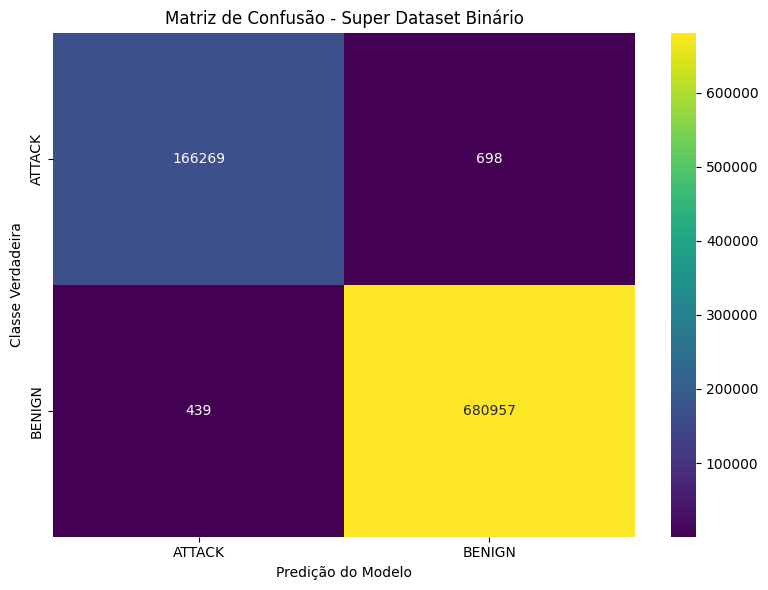

In [ ]:
# ==========================================
# MÓDULO 08: TREINAMENTO DO SUPER DATASET (MEMÓRIA OTIMIZADA)
# ==========================================
import pandas as pd
import numpy as np
import os
import gc
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
CAMINHO_SUPER = os.path.join(DIRETORIO_DATA, 'dataset_semana_unificada.parquet')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'
os.makedirs(DIRETORIO_ARTEFATOS, exist_ok=True)

print("1. Carregando o Super Dataset (Isso pode levar 1-2 minutos)...")
df = pd.read_parquet(CAMINHO_SUPER)

print("2. Separando Variáveis (Features e Target)...")
X = df.drop(columns=['Label'])
y = df['Label']

# Limpando o DataFrame original da memória RAM
del df
gc.collect()

print("3. Codificando o Alvo (Label Encoding)...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
nomes_classes = label_encoder.classes_
print(f"   Mapeamento de Classes: {nomes_classes}")
joblib.dump(label_encoder, os.path.join(DIRETORIO_ARTEFATOS, 'le_super_dataset.joblib'))

print("4. Dividindo em Treino (70%) e Teste (30%) com Estratificação...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Limpando variáveis não utilizadas da memória RAM
del X, y, y_encoded
gc.collect()

print("5. Aplicando Normalização (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(DIRETORIO_ARTEFATOS, 'scaler_super_dataset.joblib'))

# Liberar memória do X_train/X_test não escalados
del X_train, X_test
gc.collect()

print("6. Treinando o Random Forest (Isso levará alguns minutos)...")
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_scaled, y_train)
joblib.dump(modelo_rf, os.path.join(DIRETORIO_ARTEFATOS, 'rf_super_dataset.joblib'))

print("7. Realizando Predições nos dados de Teste (848 mil linhas)...")
y_pred = modelo_rf.predict(X_test_scaled)

print("\n" + "="*60)
print("📊 RELATÓRIO DE CLASSIFICAÇÃO (SUPER DATASET):")
print("="*60)
print(classification_report(y_test, y_pred, target_names=nomes_classes))

print("\n8. Gerando Matriz de Confusão...")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - Super Dataset Binário')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Predição do Modelo')
plt.tight_layout()
plt.show()

# MÓDULO 09: HIST-GRADIENT BOOSTING (SCIKIT-LEARN)

1. Carregando os Transformadores Antigos (Para ser uma luta justa)...
2. Carregando o Super Dataset...
3. Preparando os Dados (Split e Escala)...
4. Treinando o HistGradientBoostingClassifier (O trunfo do Scikit-Learn)...
5. Realizando Predições...

📊 RELATÓRIO DE CLASSIFICAÇÃO (HIST GRADIENT BOOSTING):
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00    166967
      BENIGN       1.00      1.00      1.00    681396

    accuracy                           1.00    848363
   macro avg       1.00      1.00      1.00    848363
weighted avg       1.00      1.00      1.00    848363


6. Gerando Matriz de Confusão...


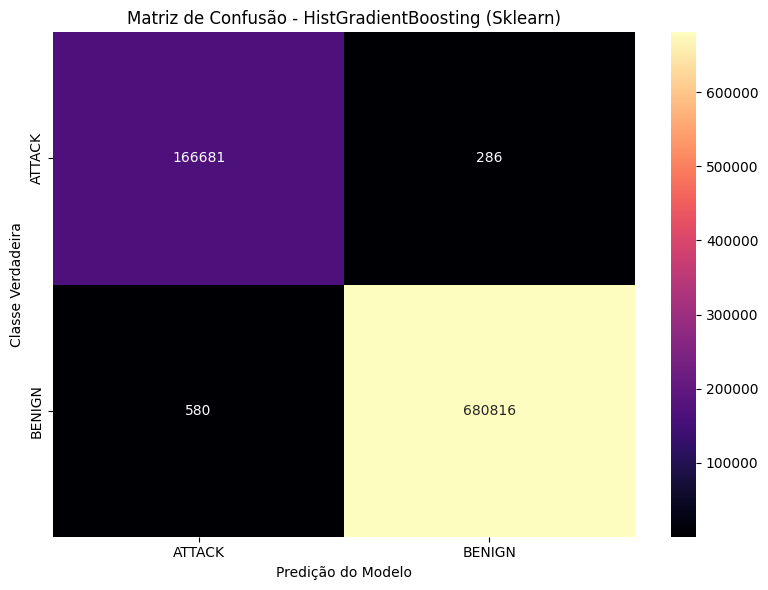

In [ ]:
# ==========================================
# MÓDULO 09: HIST-GRADIENT BOOSTING (SCIKIT-LEARN)
# ==========================================
import pandas as pd
import numpy as np
import os
import gc
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
CAMINHO_SUPER = os.path.join(DIRETORIO_DATA, 'dataset_semana_unificada.parquet')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando os Transformadores Antigos (Para ser uma luta justa)...")
scaler = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'scaler_super_dataset.joblib'))
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'le_super_dataset.joblib'))
nomes_classes = label_encoder.classes_

print("2. Carregando o Super Dataset...")
df = pd.read_parquet(CAMINHO_SUPER)
X = df.drop(columns=['Label'])
y = df['Label']
del df
gc.collect()

print("3. Preparando os Dados (Split e Escala)...")
y_encoded = label_encoder.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
del X, y, y_encoded
gc.collect()

# Normalizando com o scaler já treinado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
del X_train, X_test
gc.collect()

print("4. Treinando o HistGradientBoostingClassifier (O trunfo do Scikit-Learn)...")
# max_iter=100 é o equivalente a n_estimators. learning_rate controla a velocidade de aprendizado.
modelo_hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
modelo_hgb.fit(X_train_scaled, y_train)

# Salvando o novo modelo
joblib.dump(modelo_hgb, os.path.join(DIRETORIO_ARTEFATOS, 'hgb_super_dataset.joblib'))

print("5. Realizando Predições...")
y_pred = modelo_hgb.predict(X_test_scaled)

print("\n" + "="*60)
print("📊 RELATÓRIO DE CLASSIFICAÇÃO (HIST GRADIENT BOOSTING):")
print("="*60)
print(classification_report(y_test, y_pred, target_names=nomes_classes))

print("\n6. Gerando Matriz de Confusão...")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - HistGradientBoosting (Sklearn)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Predição do Modelo')
plt.tight_layout()
plt.show()

# MÓDULO 10: EXTRAÇÃO DE ATRIBUTOS (FEATURE SELECTION)

1. Carregando o Modelo Random Forest original...
2. Lendo apenas 1 linha do dataset para capturar o nome das colunas...
3. Mapeando a importância matemática de cada variável...

🏆 AS 15 VARIÁVEIS DE OURO PARA O ARTIGO:
                    Feature  Importancia
          Max Packet Length     0.080704
     Packet Length Variance     0.069109
       Avg Bwd Segment Size     0.065433
          Packet Length Std     0.055708
           Destination Port     0.052055
        Average Packet Size     0.051836
      Bwd Packet Length Max     0.041820
Total Length of Bwd Packets     0.037836
          Subflow Fwd Bytes     0.035056
      Bwd Packet Length Std     0.031735
Total Length of Fwd Packets     0.029626
          Subflow Bwd Bytes     0.027615
     Init_Win_bytes_forward     0.021667
     Bwd Packet Length Mean     0.021652
         Packet Length Mean     0.021503

4. Salvando a lista de variáveis para os novos modelos...

5. Gerando gráfico acadêmico...


/tmp/ipykernel_10320/987307398.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=top_15, palette='viridis')


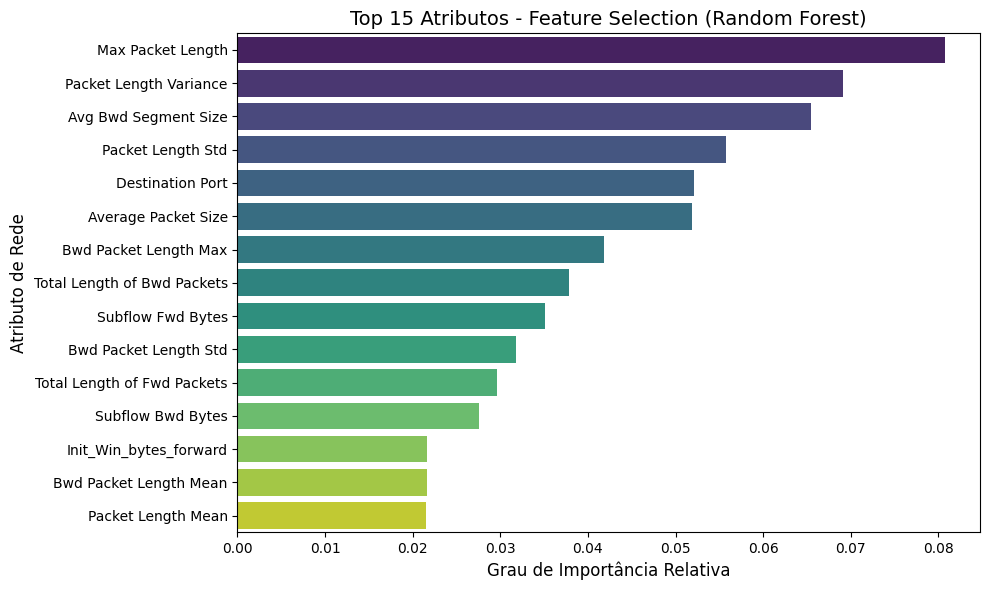

In [ ]:
# ==========================================
# MÓDULO 10: EXTRAÇÃO DE ATRIBUTOS (FEATURE SELECTION)
# ==========================================
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Caminhos
DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
CAMINHO_SUPER = os.path.join(DIRETORIO_DATA, 'dataset_semana_unificada.parquet')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando o Modelo Random Forest original...")
modelo_rf = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'rf_super_dataset.joblib'))

print("2. Lendo apenas 1 linha do dataset para capturar o nome das colunas...")
df_amostra = pd.read_parquet(CAMINHO_SUPER).head(1)
nomes_features = df_amostra.drop(columns=['Label']).columns

print("3. Mapeando a importância matemática de cada variável...")
importancias = modelo_rf.feature_importances_

df_importancias = pd.DataFrame({
    'Feature': nomes_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Selecionando as 15 variáveis mais cruciais (Top 15)
top_15 = df_importancias.head(15)
features_selecionadas = top_15['Feature'].tolist()

print("\n" + "="*50)
print("🏆 AS 15 VARIÁVEIS DE OURO PARA O ARTIGO:")
print("="*50)
print(top_15.to_string(index=False))

print("\n4. Salvando a lista de variáveis para os novos modelos...")
joblib.dump(features_selecionadas, os.path.join(DIRETORIO_ARTEFATOS, 'top_15_features.joblib'))

print("\n5. Gerando gráfico acadêmico...")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=top_15, palette='viridis')
plt.title('Top 15 Atributos - Feature Selection (Random Forest)', fontsize=14)
plt.xlabel('Grau de Importância Relativa', fontsize=12)
plt.ylabel('Atributo de Rede', fontsize=12)
plt.tight_layout()
plt.show()

# MÓDULO 11: RANDOM FOREST OTIMIZADO (TOP 15 FEATURES)

1. Carregando as 15 Variáveis Selecionadas e o Label Encoder...
2. Carregando o Dataset Massivo (Apenas colunas essenciais para poupar RAM)...
3. Dividindo os dados (Treino/Teste)...
4. Normalizando (Nova escala apenas para as 15 colunas)...
5. Treinando Random Forest 'Light' (Isso será bem mais rápido!)...
6. Resultados do Random Forest Otimizado:
              precision    recall  f1-score   support

      ATTACK       0.99      0.98      0.99    166967
      BENIGN       1.00      1.00      1.00    681396

    accuracy                           1.00    848363
   macro avg       1.00      0.99      0.99    848363
weighted avg       1.00      1.00      1.00    848363



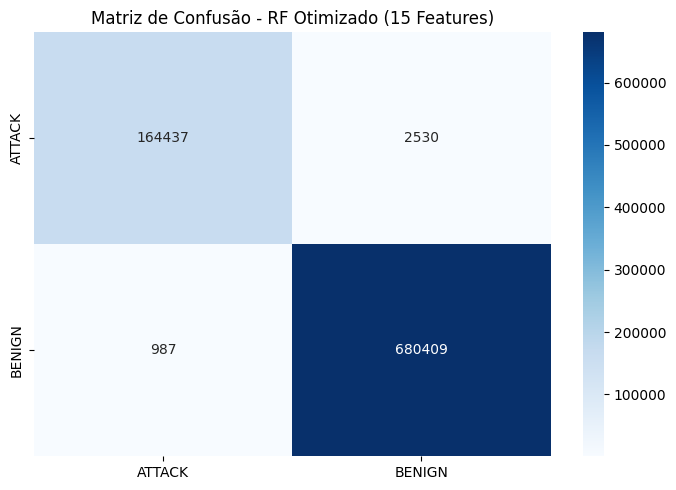

In [ ]:
# ==========================================
# MÓDULO 11: RANDOM FOREST OTIMIZADO (TOP 15 FEATURES)
# ==========================================
import pandas as pd
import numpy as np
import os
import gc
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
CAMINHO_SUPER = os.path.join(DIRETORIO_DATA, 'dataset_semana_unificada.parquet')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando as 15 Variáveis Selecionadas e o Label Encoder...")
top_15_features = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'top_15_features.joblib'))
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'le_super_dataset.joblib'))
nomes_classes = label_encoder.classes_

print("2. Carregando o Dataset Massivo (Apenas colunas essenciais para poupar RAM)...")
colunas_para_ler = top_15_features + ['Label']
df = pd.read_parquet(CAMINHO_SUPER, columns=colunas_para_ler)

X = df.drop(columns=['Label'])
y = label_encoder.transform(df['Label'])
del df
gc.collect()

print("3. Dividindo os dados (Treino/Teste)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
del X, y
gc.collect()

print("4. Normalizando (Nova escala apenas para as 15 colunas)...")
scaler_light = StandardScaler()
X_train_scaled = scaler_light.fit_transform(X_train)
X_test_scaled = scaler_light.transform(X_test)
joblib.dump(scaler_light, os.path.join(DIRETORIO_ARTEFATOS, 'scaler_light.joblib'))
del X_train, X_test
gc.collect()

print("5. Treinando Random Forest 'Light' (Isso será bem mais rápido!)...")
modelo_rf_light = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
modelo_rf_light.fit(X_train_scaled, y_train)

print("6. Resultados do Random Forest Otimizado:")
y_pred = modelo_rf_light.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=nomes_classes))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - RF Otimizado (15 Features)')
plt.tight_layout()
plt.show()

# MÓDULO 12: HIST GRADIENT BOOSTING OTIMIZADO (TOP 15 FEATURES)

1. Carregando ferramentas da versão Light...
2. Carregando e fatiando o Super Dataset...
3. Preparando os dados...
4. Treinando HistGradientBoosting 'Light'...
5. Resultados do HGB Otimizado:
              precision    recall  f1-score   support

      ATTACK       0.99      0.98      0.99    166967
      BENIGN       1.00      1.00      1.00    681396

    accuracy                           0.99    848363
   macro avg       0.99      0.99      0.99    848363
weighted avg       0.99      0.99      0.99    848363



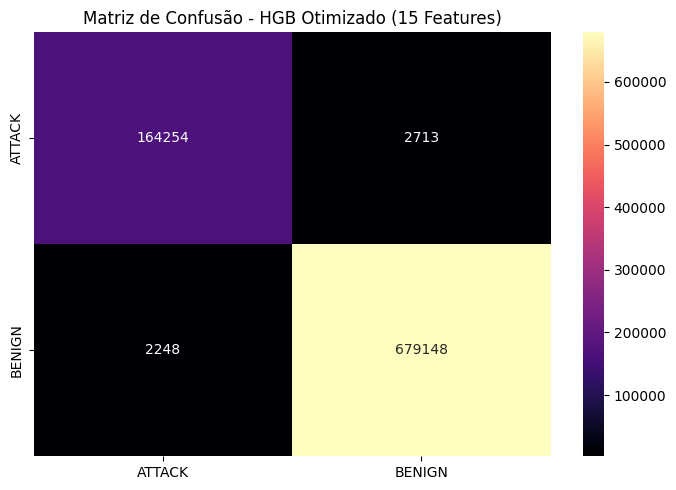

In [ ]:
# ==========================================
# MÓDULO 12: HIST GRADIENT BOOSTING OTIMIZADO (TOP 15 FEATURES)
# ==========================================
import pandas as pd
import numpy as np
import os
import gc
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

DIRETORIO_DATA = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/data'
CAMINHO_SUPER = os.path.join(DIRETORIO_DATA, 'dataset_semana_unificada.parquet')
DIRETORIO_ARTEFATOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts'

print("1. Carregando ferramentas da versão Light...")
top_15_features = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'top_15_features.joblib'))
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'le_super_dataset.joblib'))
scaler_light = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'scaler_light.joblib'))
nomes_classes = label_encoder.classes_

print("2. Carregando e fatiando o Super Dataset...")
colunas_para_ler = top_15_features + ['Label']
df = pd.read_parquet(CAMINHO_SUPER, columns=colunas_para_ler)

X = df.drop(columns=['Label'])
y = label_encoder.transform(df['Label'])
del df
gc.collect()

print("3. Preparando os dados...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
del X, y
gc.collect()

X_train_scaled = scaler_light.transform(X_train)
X_test_scaled = scaler_light.transform(X_test)
del X_train, X_test
gc.collect()

print("4. Treinando HistGradientBoosting 'Light'...")
modelo_hgb_light = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
modelo_hgb_light.fit(X_train_scaled, y_train)

print("5. Resultados do HGB Otimizado:")
y_pred = modelo_hgb_light.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=nomes_classes))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - HGB Otimizado (15 Features)')
plt.tight_layout()
plt.show()

# PIPELINE DIÁRIO: ANÁLISE MULTI-CLASSE (DIA ESPECÍFICO)

In [ ]:
# ==========================================
# PIPELINE DIÁRIO: ANÁLISE MULTI-CLASSE (DIA ESPECÍFICO)
# ==========================================
import pandas as pd
import numpy as np
import os
import gc
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PARAMETRIZAÇÃO DO DIA (Altere aqui para testar outros dias)
ARQUIVO_ALVO = 'Tuesday-WorkingHours.pcap_ISCX.csv'
NOME_EXPERIMENTO = 'Terca_ForcaBruta'

# Caminhos
EXTRACT_PATH = '/content/dataset_csv/MachineLearningCVE' # Ajuste se sua pasta base for diferente
CAMINHO_CSV = os.path.join(EXTRACT_PATH, ARQUIVO_ALVO)
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics'

os.makedirs(DIRETORIO_ARTEFATOS, exist_ok=True)
os.makedirs(DIRETORIO_GRAFICOS, exist_ok=True)

print(f"1. Carregando dados do dia: {ARQUIVO_ALVO}...")
df = pd.read_csv(CAMINHO_CSV)

print("2. Limpeza Estrutural...")
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']
del df
gc.collect()

print("3. Codificando as Classes (Multi-classe)...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
nomes_classes = label_encoder.classes_
print(f"   -> Classes identificadas: {list(nomes_classes)}")
joblib.dump(label_encoder, os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))

print("4. Dividindo em Treino (70%) e Teste (30%)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
del X, y
gc.collect()

print("5. Normalizando os dados (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(DIRETORIO_ARTEFATOS, 'scaler.joblib'))
del X_train, X_test
gc.collect()

print("6. Treinando Modelos (Random Forest vs HistGradientBoosting)...")
# Random Forest
rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# HistGradientBoosting
hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
hgb.fit(X_train_scaled, y_train)
y_pred_hgb = hgb.predict(X_test_scaled)

print("\n" + "="*50)
print(f"📊 RESULTADOS GLOBAIS - {NOME_EXPERIMENTO.upper()}")
print("="*50)
print("--- RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf, target_names=nomes_classes))
print("--- HIST GRADIENT BOOSTING ---")
print(classification_report(y_test, y_pred_hgb, target_names=nomes_classes))

print("\n7. Gerando Gráfico Comparativo IEEE...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.rcParams['font.family'] = 'sans-serif'

# Matriz RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"weight": "bold"})
ax1.set_title(f'(a) Random Forest ({NOME_EXPERIMENTO})', fontweight='bold', pad=15)
ax1.set_ylabel('Classe Verdadeira', fontweight='bold')
ax1.set_xlabel('Classe Predita', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Matriz HGB
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
sns.heatmap(cm_hgb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax2,
            xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"weight": "bold"})
ax2.set_title(f'(b) HistGradientBoosting ({NOME_EXPERIMENTO})', fontweight='bold', pad=15)
ax2.set_ylabel('')
ax2.set_xlabel('Classe Predita', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

caminho_grafico = os.path.join(DIRETORIO_GRAFICOS, f'matrizes_{NOME_EXPERIMENTO}.pdf')
plt.savefig(caminho_grafico, bbox_inches='tight')
plt.show()

print(f"✅ Execução concluída! Artefatos e gráfico salvos.")

1. Carregando dados do dia: Tuesday-WorkingHours.pcap_ISCX.csv...


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_csv/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv'